In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
import joblib
import os

# 1. تثبيت الأرقام العشوائية لضمان تكرار نفس النتائج (Seeds) حسب دليل المشروع
np.random.seed(42)

# 2. تحميل البيانات مباشرة من الإنترنت (بدون ما تحتاج تحمل ملف على جهازك!)
print("⏳ جاري تحميل بيانات الـ SMS Spam من الإنترنت تلقائياً...")
url = 'https://raw.githubusercontent.com/justmarkham/DAT8/master/data/sms.tsv'
# البيانات هنا مفصولة بـ Tab وليس فاصلة، لذا نستخدم sep='\t'
df = pd.read_csv(url, sep='\t', header=None, names=['label', 'text'])

# تحويل التسميات إلى أرقام: spam = 1 و ham = 0
df['label'] = df['label'].map({'ham': 0, 'spam': 1})
print("✅ تم تحميل البيانات وجاهزة للعمل!")

# 3. تقسيم البيانات إلى: تدريب (Train)، تحقق (Validation)، واختبار (Test) حسب شروط المشروع
X_train_full, X_test, y_train_full, y_test = train_test_split(
    df['text'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, random_state=42, stratify=y_train_full
)

print(f"\n📁 تقسيمات البيانات:")
print(f"🔹 حجم بيانات التدريب: {X_train.shape[0]}")
print(f"🔹 حجم بيانات التحقق: {X_val.shape[0]}")
print(f"🔹 حجم بيانات الاختبار (مخفية للتقييم النهائي): {X_test.shape[0]}")

# 4. معالجة النصوص وتحويلها إلى أرقام (TF-IDF Vectorizer)
vectorizer = TfidfVectorizer(stop_words='english', max_features=3000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)

# 5. بناء وتدريب نموذج الـ Baseline (Random Forest)
print("\n🧠 جاري تدريب نموذج الذكاء الاصطناعي...")
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_tfidf, y_train)

# 6. قياس دقة التجربة على بيانات التحقق (Validation Accuracy)
val_accuracy = model.score(X_val_tfidf, y_val)
print(f"🎯 دقة النموذج الحالية على بيانات التحقق: {val_accuracy * 100:.2f}%")

# 7. إنشاء مجلد وحفظ النموذج والـ vectorizer بداخل Colab
os.makedirs('models', exist_ok=True)
joblib.dump(model, 'models/spam_rf_model.pkl')
joblib.dump(vectorizer, 'models/tfidf_vectorizer.pkl')
print("\n💾 ممتاز! تم حفظ النموذج بنجاح في مجلد models/ داخل Colab.")

⏳ جاري تحميل بيانات الـ SMS Spam من الإنترنت تلقائياً...
✅ تم تحميل البيانات وجاهزة للعمل!

📁 تقسيمات البيانات:
🔹 حجم بيانات التدريب: 3788
🔹 حجم بيانات التحقق: 669
🔹 حجم بيانات الاختبار (مخفية للتقييم النهائي): 1115

🧠 جاري تدريب نموذج الذكاء الاصطناعي...
🎯 دقة النموذج الحالية على بيانات التحقق: 97.46%

💾 ممتاز! تم حفظ النموذج بنجاح في مجلد models/ داخل Colab.


🎯 الدقة النهائية الحقيقية على بيانات الاختبار: 97.58%

📊 تقرير التصنيف بالتفصيل:
              precision    recall  f1-score   support

Ham (Normal)       0.97      1.00      0.99       966
        Spam       1.00      0.82      0.90       149

    accuracy                           0.98      1115
   macro avg       0.99      0.91      0.94      1115
weighted avg       0.98      0.98      0.97      1115


🖼️ جاري رسم مصفوفة الارتباك وحفظها...


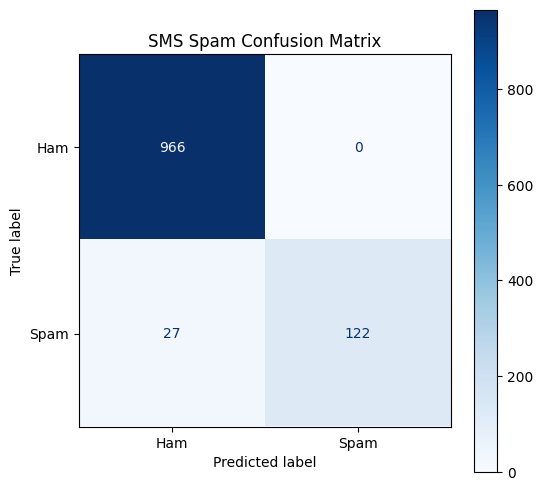

✅ تم حفظ مصفوفة الارتباك في مجلد reports/ confusion_matrix.png

🔍 استعراض بعض الرسائل التي أخطأ النموذج في تصنيفها:

❌ رسالة رقم 1:
النص: FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, £1.50 to rcv
التصنيف الحقيقي: Spam | تصنيف النموذج الخاطئ: Ham
--------------------------------------------------

❌ رسالة رقم 2:
النص: Hi if ur lookin 4 saucy daytime fun wiv busty married woman Am free all next week Chat now 2 sort time 09099726429 JANINExx Calls£1/minMobsmoreLKPOBOX177HP51FL
التصنيف الحقيقي: Spam | تصنيف النموذج الخاطئ: Ham
--------------------------------------------------

❌ رسالة رقم 3:
النص: ringtoneking 84484
التصنيف الحقيقي: Spam | تصنيف النموذج الخاطئ: Ham
--------------------------------------------------


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. حساب الدقة النهائية على بيانات الاختبار (اللي ما شافها النموذج أبدًا)
X_test_tfidf = vectorizer.transform(X_test)
test_accuracy = model.score(X_test_tfidf, y_test)
print(f"🎯 الدقة النهائية الحقيقية على بيانات الاختبار: {test_accuracy * 100:.2f}%\n")

# 2. طباعة تقرير التصنيف بالتفصيل (Precision, Recall, F1-Score)
y_pred = model.predict(X_test_tfidf)
print("📊 تقرير التصنيف بالتفصيل:")
print(classification_report(y_test, y_pred, target_names=['Ham (Normal)', 'Spam']))

# 3. رسم مصفوفة الارتباك (Confusion Matrix) وحفظها تلقائيًا
print("\n🖼️ جاري رسم مصفوفة الارتباك وحفظها...")
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ham', 'Spam'])

# تخصيص الرسمة وشكلها
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('SMS Spam Confusion Matrix')

# إنشاء مجلد reports وحفظ الرسمة داخله بصيغة png
os.makedirs('reports', exist_ok=True)
plt.savefig('reports/confusion_matrix.png', bbox_inches='tight')
plt.show()
print("✅ تم حفظ مصفوفة الارتباك في مجلد reports/ confusion_matrix.png")

# 4. تحليل الأخطاء (Error Analysis) - عرض بعض الرسائل اللي غلط فيها النموذج
print("\n🔍 استعراض بعض الرسائل التي أخطأ النموذج في تصنيفها:")
misclassified_idx = np.where(y_pred != y_test)[0]

if len(misclassified_idx) == 0:
    print("الموديل أسطوري ولم يخطئ في أي رسالة!")
else:
    # عرض أول 3 رسائل أخطأ فيها النموذج لقراءتها وتحليلها
    count = 0
    for idx in misclassified_idx:
        if count >= 3: break
        true_lbl = 'Spam' if y_test.iloc[idx] == 1 else 'Ham'
        pred_lbl = 'Spam' if y_pred[idx] == 1 else 'Ham'
        print(f"\n❌ رسالة رقم {count+1}:")
        print(f"النص: {X_test.iloc[idx]}")
        print(f"التصنيف الحقيقي: {true_lbl} | تصنيف النموذج الخاطئ: {pred_lbl}")
        print("-" * 50)
        count += 1